## 0. Введение

Этот ноутбук демонстрирует использование `manuscript-ocr` версии >= 0.1.11 совместно с внешним сервисом постобработки текста. В данном примере показано, как результаты распознавания, полученные в pipeline, могут быть дополнительно обработаны с помощью сервиса `Yandex Speller`.

`Yandex Speller` в данном ноутбуке используется только как пример внешнего корректора. Этот сервис не является частью репозитория `manuscript-ocr`, не входит в состав проекта и не распространяется вместе с ним. Обращение к сервису выполняется через внешний HTTP API, поэтому работоспособность примера зависит от наличия сетевого доступа и доступности сервиса со стороны Яндекса.

Минимальные технические требования для запуска примера:

- Python 3.8+
- не менее 8 ГБ оперативной памяти
- доступ в интернет для обращения к сервису `Yandex Speller`
- GPU для запуска примера не является обязательным

При использовании GPU для этапов детекции и распознавания рекомендуется видеокарта с объемом памяти от 4 ГБ. При этом сам этап коррекции через `Yandex Speller` в GPU не нуждается.

## 1. Установка зависимостей

In [ ]:
!pip install "manuscript-ocr>=0.1.11"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.2/574.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 96.7 MB/s eta 0:00:00


Если требуется запуск с использованием GPU, необходимо заменить CPU-версию ONNX Runtime на GPU-версию:

In [2]:
# Удалите CPU-версию ONNX Runtime
!pip uninstall onnxruntime

# Установите GPU-версию
!pip install onnxruntime-gpu

Found existing installation: onnxruntime 1.24.4
Uninstalling onnxruntime-1.24.4:
  Would remove:
    /usr/local/bin/onnxruntime_test
    /usr/local/lib/python3.12/dist-packages/onnxruntime-1.24.4.dist-info/*
    /usr/local/lib/python3.12/dist-packages/onnxruntime/*
Proceed (Y/n)? y
  Successfully uninstalled onnxruntime-1.24.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 1.7 MB/s eta 0:00:00


## 2. Определение корректора через яндекс спеллер

Согласно документации для версии `0.1.11` и выше, корректор в `Pipeline` должен реализовать метод `predict`, который принимает объект `Page` и при необходимости исходное изображение, а затем возвращает обновленный объект `Page`.

В общем виде интерфейс корректора выглядит так:

`predict(self, page: Page, image=None) -> Page`

В данном примере `YandexSpellerCorrector` получает объект `Page` с уже распознанным текстом, выполняет постобработку слов с помощью внешнего сервиса `Yandex Speller` и возвращает обновленный объект `Page`.

In [3]:
import requests
from typing import Any, Optional

from manuscript.data import Page


class YandexSpellerCorrector:
    SPELLER_URL = "https://speller.yandex.net/services/spellservice.json/checkText"

    def __init__(self, lang: str = "ru", timeout: float = 2.0):
        self.lang = lang
        self.timeout = timeout

    def predict(self, page: Page, image: Optional[Any] = None) -> Page:
        result = page.model_copy(deep=True)

        for block in result.blocks:
            for line in block.lines:
                for span in line.text_spans:
                    if not span.text:
                        continue
                    span.text = self._correct_text(span.text)

        return result

    def _correct_text(self, text: str) -> str:
        try:
            response = requests.get(
                self.SPELLER_URL,
                params={
                    "text": text,
                    "lang": self.lang,
                },
                timeout=self.timeout,
            )
            response.raise_for_status()
            fixes = response.json()

            if not fixes:
                return text

            corrected = text
            for fix in reversed(fixes):
                suggestions = fix.get("s") or []
                if not suggestions:
                    continue

                start = fix["pos"]
                end = start + fix["len"]
                corrected = corrected[:start] + suggestions[0] + corrected[end:]

            return corrected

        except Exception:
            return text


## 3. Пример запуска

[YOLO] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
[TRBA] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
{'page': Page(blocks=[Block(lines=[Line(text_spans=[TextSpan(polygon=[(115.29444122314453, 153.7332305908203), (206.50730895996094, 153.7332305908203), (206.50730895996094, 268.6808166503906), (115.29444122314453, 268.6808166503906)], detection_confidence=0.56591796875, text='30', recognition_confidence=0.9953293800354004, order=0)], order=0)], text_spans=[], order=0), Block(lines=[Line(text_spans=[TextSpan(polygon=[(259.7632751464844, 154.29368591308594), (349.6898498535156, 154.29368591308594), (349.6898498535156, 288.08520507

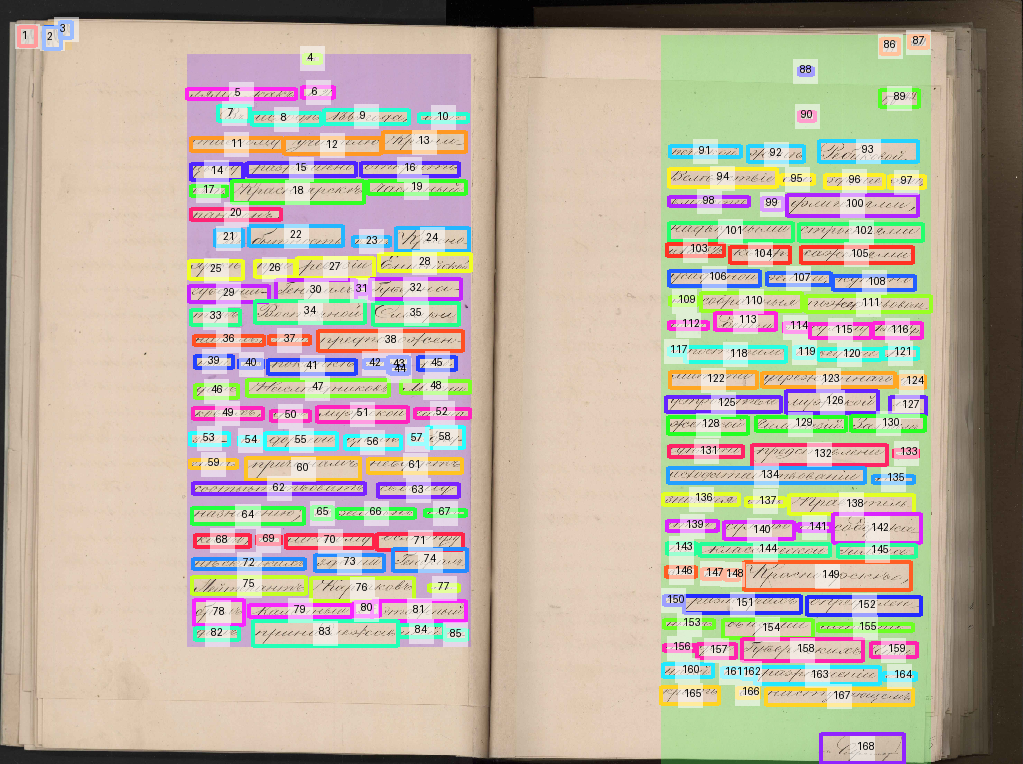

In [5]:
from pathlib import Path
from urllib.request import urlretrieve

from manuscript import Pipeline
from manuscript.utils.visualization import visualize_page

image_url = "https://raw.githubusercontent.com/konstantinkozhin/manuscript-ocr/main/example/images/img1.jpeg"
image_path = Path("img1.jpeg")

if not image_path.exists():
    urlretrieve(image_url, image_path)

pipeline = Pipeline(
    corrector=YandexSpellerCorrector(),
)

result = pipeline.predict(str(image_path))

print(result)

text = pipeline.get_text(result["page"])
print(text)

visualize_page(
    str(image_path),
    result["page"],
    show_lines=False,
    show_numbers=True,
    max_size=1024,
)

Следует учитывать, что качество коррекции в данном примере является результатом работы внешнего сервиса `Yandex Speller`, а не собственной модели библиотеки `manuscript-ocr`. Поэтому итоговое качество зависит главным образом от подключенного сервиса коррекции.

Таким образом, пример показывает, что `manuscript-ocr` может быть интегрирован с внешними сервисами постобработки текста без существенных доработок.